# Optimizing the Piezo Position

``` Pseudo
1. Get scanners current position
2. Set resolution (we know range will be 1 um in the xy plane)
3. Build the sequence, centered around the current position
4. For each position in sequence, go to that position and take an image
5. Calculate the total brightness for each image, and fit a gaussian distribution to the sequence
6. Plot
```

### Scanner Architecture: GUI to Hardware

- **For positioning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_ao** → Hardware
- **For scanning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_finite_sampling_io** → Hardware
- Interfuse selects appropriate hardware
Piezo stages: x, y, z axes
    - ao0 → x-axis
    - ao1 → y-axis  
    - ao2 → z-axis

## Camera and Diamond Specs
- 1 SPAD pixel = 0.5 microns
- Spacing between each NV = 1 micron

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import cv2
import torch
import torch.nn.functional as F
import time

## Getting initial position of mask
- Get centroid of brightness
- Center mask on brightness

## SPAD Configuration

In [2]:
spad = camera_SPC3
spad._apply_camera_settings()

piezo = scanning_probe_logic

laser = dlnsec_laser

### Optimization Params
- resolution_x = 3 # pixels
- resolution_y = 3 # pixels
- scan_range_x = 1e-6 # units are in m; 1 micron for both x and y ensures pixel is centered on nv
- scan_range_y = 1e-6

## Subtract Background

### Laser States
- OFF = 0
- ON = 1
- LOCKED = 2
- UNKNOWN = 3

In [ ]:
def take_bg_image(spad, laser, n_bg_frames=100):
    spad._NFrames = n_bg_frames

    laser.set_laser_state(0) # turn laser off    
    time.sleep(1)  # wait a moment to ensure laser is off


    success = spad.capture_background_image()
    spad.enable_background_subtraction()
    spad._NFrames = 1 

    laser.set_laser_state(1) # turn laser on

    if success == False:
        raise RuntimeError("Failed to capture background image.")
    else:
        print("Background image captured successfully.")
    
    bg_frame = spad._background_image

            h, w = spad.get_size()
        bg_frame = np.array(spad._background_image).reshape(h, w)

    time.sleep(1)  # wait a moment to ensure laser is back on

    return bg_img # flattened background image

def get_frames(spad, n_frames=1):
    spad._NFrames = n_frames
    frames = spad.start_single_acquisition().squeeze()
    
    frames = np.array(frames).astype('float32')

    if spad._background_subtraction_enabled:
        if not hasattr(spad, "_background_image") or spad._background_image is None:
            raise ValueError("Background subtraction is enabled, but no background image is set.")
        
        h, w = spad.get_size()
        bg_frame = np.array(spad._background_image).reshape(h, w)
        

        frames = frames - bg_frame
        frames = np.clip(frames, 0, None)
    
    return frames

spad.disable_background_subtraction()
laser.set_laser_state(1)
before_bg = get_frames(spad, n_frames=1)
bg = take_bg_image(spad, laser, n_bg_frames=5)
h, w = spad.get_size()
bg_frame = bg.reshape(h, w)
after_bg = get_frames(spad, n_frames=1)

Background image captured successfully.


Background subtraction enabled: True


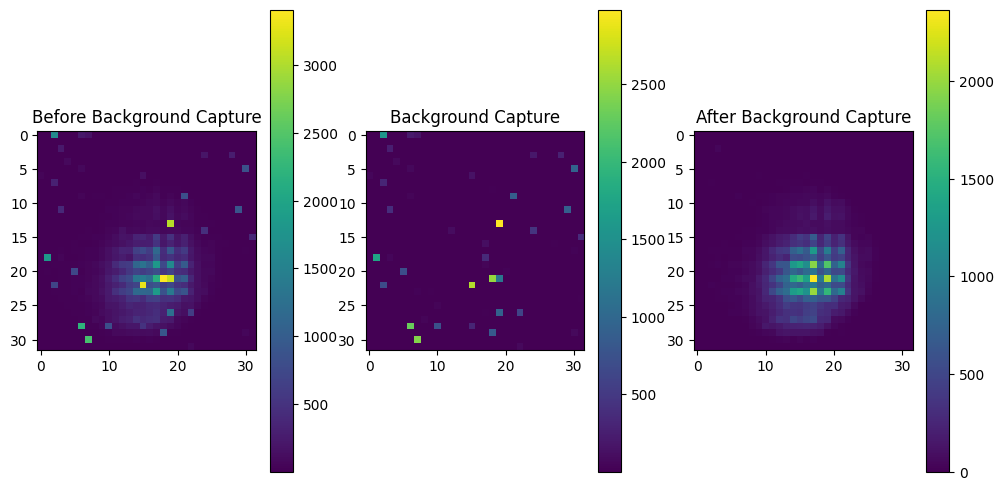

In [6]:
print(f"Background subtraction enabled: {spad._background_subtraction_enabled}")

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title("Before Background Capture")  
plt.imshow(before_bg)
plt.colorbar()
plt.subplot(1,3,2)
plt.title("Background Capture")  
plt.imshow(bg.reshape(spad.get_size()))
plt.colorbar()
plt.subplot(1,3,3)
plt.title("After Background Capture")  
plt.imshow(after_bg)
plt.colorbar()


## Find Centroid (Brightness) of Image

In [4]:
crop_dim = 14 # 14 pixels and 7 microns

def find_centroid(image):
    """Find the centroid of the bright spot in the image."""
    M = cv2.moments(image)
    if M["m00"] == 0:
        return (image.shape[1] // 2, image.shape[0] // 2)  # Return center if no mass
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    return (cX, cY)

init_image = np.array(spad.start_single_acquisition()[0, 0, :, :])
centroid = find_centroid(np.flipud(init_image))
x_center, y_center = centroid
print(f"Centroid found at: ({x_center}, {y_center})")
plt.imshow(init_image)

TypeError: 'NoneType' object is not subscriptable

## Building the Sequence

In [ ]:
resolution_x = 15 # pixels
resolution_y = 15 # pixels
scan_range_x = 1.0e-6 # meters
scan_range_y = 1.0e-6 # meters
arr_dim = 5 # what are the number of nv's in each row and column of the array


x_l_bound, x_u_bound = piezo.scanner_constraints.axes['x'].position.bounds
y_l_bound, y_u_bound = piezo.scanner_constraints.axes['y'].position.bounds

# Build sequence
curr_pos = piezo.scanner_position
start_x = curr_pos['x'] - scan_range_x / 2
start_y = curr_pos['y'] - scan_range_y / 2
sequence_x = np.linspace(start_x, start_x + scan_range_x, int(resolution_x))
sequence_y = np.linspace(start_y, start_y + scan_range_y, int(resolution_y))

# Check params
w, h = spad.get_size()
array_size_microns = 2 * arr_dim - 1 
pxl_per_micron_x = w / array_size_microns  # 32 pixels / 9 microns = 3.56 pxl/micron
pxl_per_micron_y = h / array_size_microns
# get rid of this, because each nv is 1 pixel and there is one pixel between those pixels
# 1 pixel 0.5 microns

if sequence_x[0] < x_l_bound or sequence_x[-1] > x_u_bound:
    raise ValueError(f"X scan range [{sequence_x[0]:.2e}, {sequence_x[-1]:.2e}] m exceeds scanner bounds [{x_l_bound:.2e}, {x_u_bound:.2e}] m")

if sequence_y[0] < y_l_bound or sequence_y[-1] > y_u_bound:
    raise ValueError(f"Y scan range [{sequence_y[0]:.2e}, {sequence_y[-1]:.2e}] m exceeds scanner bounds [{y_l_bound:.2e}, {y_u_bound:.2e}] m")

print(curr_pos)

{'x': 0.000178909, 'y': 2.24452e-05, 'z': 0.0001051607}


## Sampling Images in the XY-Plane

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [ ]:
img_samples = np.zeros((resolution_x * resolution_y, h, w), dtype=np.float32)
pos_dict = {k: float(v) for k, v in curr_pos.items()}

idx = 0
for y_sample in sequence_y:
    for x_sample in sequence_x:
        pos_dict['x'] = float(x_sample)
        pos_dict['y'] = float(y_sample)
        
        position = piezo.set_target_position(pos_dict, move_blocking=True)
        
        frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
        img_samples[idx] = np.flipud(frame)
        idx += 1
        print(f"Captured frame {idx}/{resolution_x * resolution_y}")

print(f"Final shape: {img_samples.shape}")

Captured frame 1/100
Captured frame 2/100
Captured frame 3/100
Captured frame 4/100
Captured frame 5/100
Captured frame 6/100
Captured frame 7/100
Captured frame 8/100
Captured frame 9/100
Captured frame 10/100
Captured frame 11/100
Captured frame 12/100
Captured frame 13/100
Captured frame 14/100
Captured frame 15/100
Captured frame 16/100
Captured frame 17/100
Captured frame 18/100
Captured frame 19/100
Captured frame 20/100
Captured frame 21/100
Captured frame 22/100
Captured frame 23/100
Captured frame 24/100
Captured frame 25/100
Captured frame 26/100
Captured frame 27/100
Captured frame 28/100
Captured frame 29/100
Captured frame 30/100
Captured frame 31/100
Captured frame 32/100
Captured frame 33/100
Captured frame 34/100
Captured frame 35/100
Captured frame 36/100
Captured frame 37/100
Captured frame 38/100
Captured frame 39/100
Captured frame 40/100
Captured frame 41/100
Captured frame 42/100
Captured frame 43/100
Captured frame 44/100
Captured frame 45/100
Captured frame 46/1

## Calculating the Brightness Using a Kernel

In [ ]:
img_samples = np.nan_to_num(img_samples, 0)

def sum_array_batched(imgs, pxl_per_micron_x, pxl_per_micron_y):
    imgs = torch.from_numpy(imgs).float().unsqueeze(1)

    nv_size_x = int(pxl_per_micron_x)  # pixels per NV
    nv_size_y = int(pxl_per_micron_y)

    # Kernel stride
    spacing_x = int(2 * pxl_per_micron_x)  
    spacing_y = int(2 * pxl_per_micron_y)
    stride = (spacing_y, spacing_x)

    # Kernel = 1 micron NV box
    kernel = torch.ones((1, 1, nv_size_y, nv_size_x), dtype=imgs.dtype)

    out = F.conv2d(imgs, kernel, stride=stride, padding=0)
    brightness = out.squeeze(1).cpu().numpy()
    return brightness

# replace with summation

nv_brightness = sum_array_batched(imgs=img_samples, pxl_per_micron_x=pxl_per_micron_x, pxl_per_micron_y=pxl_per_micron_y)

print(f"Original: {img_samples.shape}")
print(f"Array FOV: {array_size_microns} microns")
print(f"Pixels per micron: {pxl_per_micron_x:.2f}")
print(f"NV size: {int(pxl_per_micron_x)}x{int(pxl_per_micron_y)} pixels")
print(f"Result: {nv_brightness.shape}")

Original: (100, 32, 32)
Array FOV: 9 microns
Pixels per micron: 3.56
NV size: 3x3 pixels
Result: (100, 5, 5)


In [ ]:
nv_brightness = np.sum(nv_brightness, axis=(1, 2)) # Sum across NV cells -> shape: (resolution_y * resolution_x,)
nv_brightness = np.reshape(nv_brightness, (resolution_y, resolution_x)) # Reshape to 2D grid: (resolution_y, resolution_x)

## Frame with Max Brightness

Captured frame 1/5
Captured frame 2/5
Captured frame 3/5
Captured frame 4/5
Captured frame 5/5


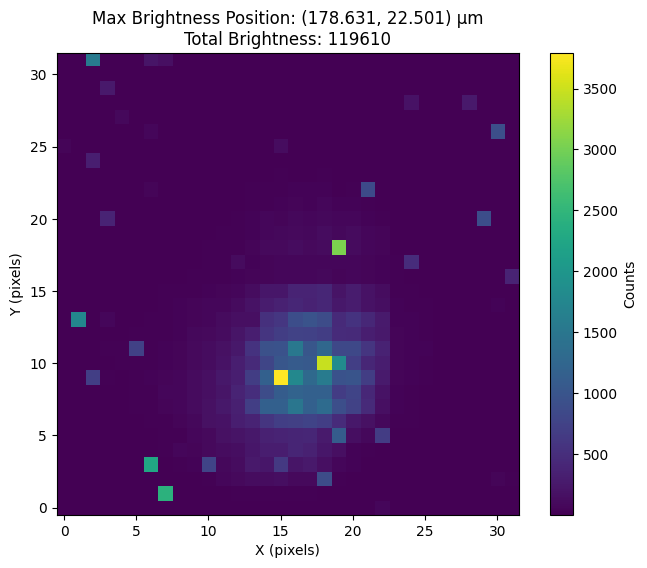

Position indices: row=5, col=2
Physical position: x=178.631 µm, y=22.501 µm
Max value in nv_brightness array: 26400.0
Total frame brightness: 119610


In [ ]:
row_max, col_max = np.unravel_index(np.argmax(nv_brightness), nv_brightness.shape)

X_grid, Y_grid = np.meshgrid(sequence_x, sequence_y, indexing="xy")
pos_x_max = X_grid[row_max, col_max]
pos_y_max = Y_grid[row_max, col_max]

pos_dict['x'] = float(pos_x_max)
pos_dict['y'] = float(pos_y_max)

position = piezo.set_target_position(pos_dict, move_blocking=True)

frames = []
for i in range(5):
    single_frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
    frames.append(single_frame)
    print(f"Captured frame {i+1}/5")

frame = np.mean(frames, axis=0)
frame = np.flipud(frame)
total_brightness = np.sum(frame)

plt.figure(figsize=(8, 6))
plt.imshow(frames[-1], origin='lower')
plt.colorbar(label='Counts')
plt.title(f'Max Brightness Position: ({pos_x_max*1e6:.3f}, {pos_y_max*1e6:.3f}) µm\nTotal Brightness: {total_brightness:.0f}')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.show()

print(f"Position indices: row={row_max}, col={col_max}")
print(f"Physical position: x={pos_x_max*1e6:.3f} µm, y={pos_y_max*1e6:.3f} µm")
print(f"Max value in nv_brightness array: {nv_brightness[row_max, col_max]:.1f}")
print(f"Total frame brightness: {total_brightness:.0f}")

## Create Overlap Function and Fit Data - CHECK

Captured frame 1/5
Captured frame 2/5
Captured frame 3/5
Captured frame 4/5
Captured frame 5/5
Peak location: 0.00017879108816414965 2.2457656786474757e-05
A, C: 2339.3513900615903 24021.243343314243
R-Squared: 0.525
RMSE: 383.871


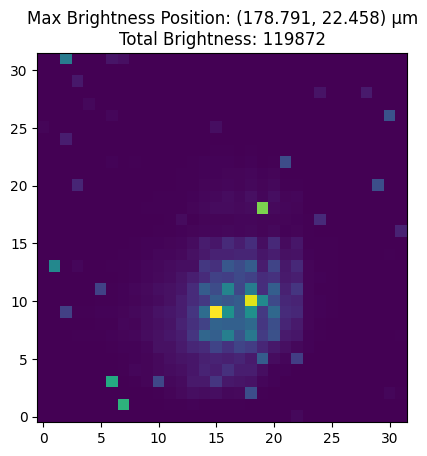

In [ ]:
def square_overlap_area(dx, dy):
    overlap_x = np.maximum(0.0, 1.0 - np.abs(dx))
    overlap_y = np.maximum(0.0, 1.0 - np.abs(dy))
    return overlap_x * overlap_y

def overlap_model(XY, amplitude, x_center, y_center, background):
    x, y = XY
    dx_norm = (x - x_center) / scan_range_x
    dy_norm = (y - y_center) / scan_range_y
    return (amplitude * square_overlap_area(dx_norm, dy_norm) + background).ravel()


X, Y = np.meshgrid(sequence_x, sequence_y, indexing="xy")

row_max, col_max = np.unravel_index(np.argmax(nv_brightness), nv_brightness.shape)

x_center_guess = X[row_max, col_max]
y_center_guess = Y[row_max, col_max]
background_guess = float(np.min(nv_brightness))
amplitude_guess = float(nv_brightness[row_max, col_max] - background_guess)

p0 = (
    amplitude_guess,
    x_center_guess,
    y_center_guess,
    background_guess,
)

bounds = (
    [0.0, sequence_x[0], sequence_y[0], 0.0],
    [np.inf, sequence_x[-1], sequence_y[-1], np.inf]
)

popt, _ = curve_fit(
    overlap_model,
    (X, Y),
    nv_brightness.ravel(),
    p0=p0,
    bounds=bounds
)

A_fit, x0_fit, y0_fit, C_fit = popt

dx_norm = (X - x0_fit) / scan_range_x
dy_norm = (Y - y0_fit) / scan_range_y
pred = A_fit * square_overlap_area(dx_norm, dy_norm) + C_fit
resid = nv_brightness - pred

sse = float(np.sum(resid**2))
sst = float(np.sum((nv_brightness - np.mean(nv_brightness))**2))
r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
rmse = float(np.sqrt(np.mean(resid**2)))

pos_dict['x'], pos_dict['y'] = float(x0_fit), float(y0_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)

frames = []
for i in range(5):
    single_frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
    frames.append(single_frame)
    print(f"Captured frame {i+1}/5")

frame = np.mean(frames, axis=0)
frame = np.flipud(frame)
total_brightness = np.sum(frame)
plt.title(f'Max Brightness Position: ({x0_fit*1e6:.3f}, {y0_fit*1e6:.3f}) µm\nTotal Brightness: {total_brightness:.0f}')
plt.imshow(frames[-1], origin='lower')

print("Peak location:", x0_fit, y0_fit)
print("A, C:", A_fit, C_fit)
print(f"R-Squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

## Plot Fit - CHECK

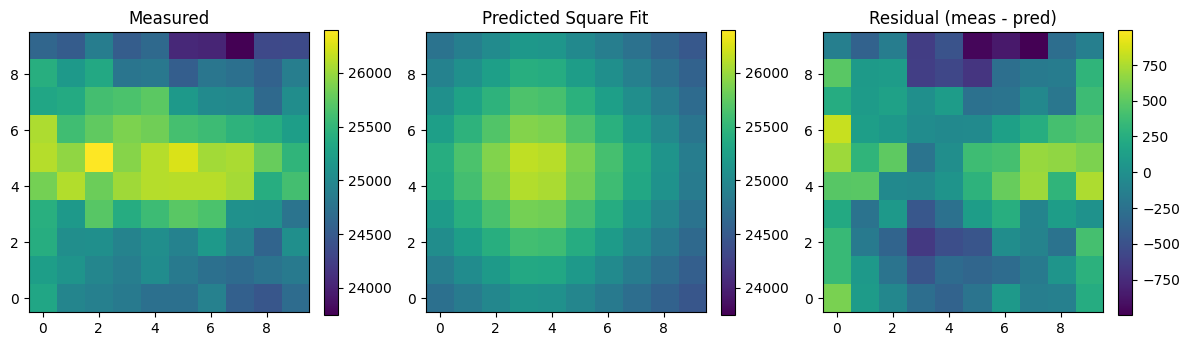

In [ ]:
plt.figure(figsize=(12, 4))

vmin = min(nv_brightness.min(), pred.min())
vmax = max(nv_brightness.max(), pred.max())

plt.subplot(1, 3, 1)
plt.title("Measured")
plt.imshow(nv_brightness, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 2)
plt.title("Predicted Square Fit")
plt.imshow(pred, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 3)
plt.title("Residual (meas - pred)")
m = np.max(np.abs(resid))
plt.imshow(resid, origin="lower", vmin=-m, vmax=m)
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()


Peak location: 0.00017867907371876146 2.2468651454170728e-05
amplitude, background: 1655.7971495897605 24546.12296880506
sigma_x, sigma_y: 6.656740085772075e-07 2.1307146913357722e-07
R-Squared: 0.795
RMSE: 251.982
Captured frame 1/5
Captured frame 2/5
Captured frame 3/5
Captured frame 4/5
Captured frame 5/5


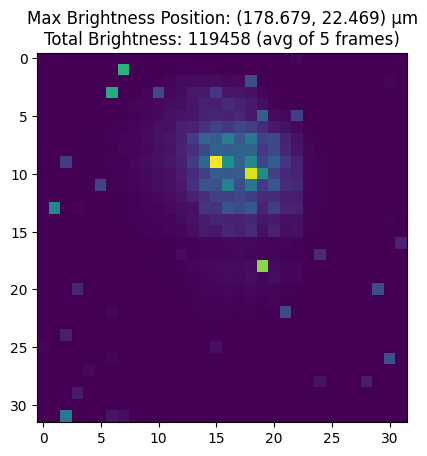

In [ ]:
def gaussian_2d(XY, amplitude, x_center, y_center, sigma_x, sigma_y, background):
    x, y = XY
    g = background + amplitude * np.exp(
        -(((x - x_center) ** 2) / (2 * sigma_x ** 2) +
          ((y - y_center) ** 2) / (2 * sigma_y ** 2))
    )
    return g.ravel()

X, Y = np.meshgrid(sequence_x, sequence_y, indexing="xy")
z = nv_brightness.astype(float)

row_max, col_max = np.unravel_index(np.argmax(z), z.shape)
x_center_guess = X[row_max, col_max]
y_center_guess = Y[row_max, col_max]
background_guess = float(np.min(z))
amplitude_guess = float(z[row_max, col_max] - background_guess)

scan_range_x_local = float(sequence_x.max() - sequence_x.min())
scan_range_y_local = float(sequence_y.max() - sequence_y.min())
sigma_x_guess = scan_range_x_local / 4.0 if scan_range_x_local > 0 else 1.0
sigma_y_guess = scan_range_y_local / 4.0 if scan_range_y_local > 0 else 1.0

p0 = (amplitude_guess, x_center_guess, y_center_guess, sigma_x_guess, sigma_y_guess, background_guess)

bounds = (
    [0.0, sequence_x.min(), sequence_y.min(), 1e-12, 1e-12, -np.inf],
    [np.inf, sequence_x.max(), sequence_y.max(), np.inf, np.inf,  np.inf],
)

popt, _ = curve_fit(
    gaussian_2d,
    (X, Y),
    z.ravel(),
    p0=p0,
    bounds=bounds
)

amplitude_fit, x_center_fit, y_center_fit, sigma_x_fit, sigma_y_fit, background_fit = popt

pred = (background_fit + amplitude_fit * np.exp(
    -(((X - x_center_fit) ** 2) / (2 * sigma_x_fit ** 2) +
      ((Y - y_center_fit) ** 2) / (2 * sigma_y_fit ** 2))
))

resid = z - pred

sse = float(np.sum(resid**2))
sst = float(np.sum((z - np.mean(z))**2))
r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
rmse = float(np.sqrt(np.mean(resid**2)))

print("Peak location:", x_center_fit, y_center_fit)
print("amplitude, background:", amplitude_fit, background_fit)
print("sigma_x, sigma_y:", sigma_x_fit, sigma_y_fit)
print(f"R-Squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

pos_dict["x"], pos_dict["y"] = float(x_center_fit), float(y_center_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)

frames = []
for i in range(5):
    single_frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
    frames.append(single_frame)
    print(f"Captured frame {i+1}/5")

frame = np.mean(frames, axis=0)
frame = np.flipud(frame)
total_brightness = np.sum(frame)
plt.title(f'Max Brightness Position: ({x_center_fit*1e6:.3f}, {y_center_fit*1e6:.3f}) µm\nTotal Brightness: {total_brightness:.0f} (avg of 5 frames)')
plt.imshow(frames[-1], origin='lower')
plt.show()

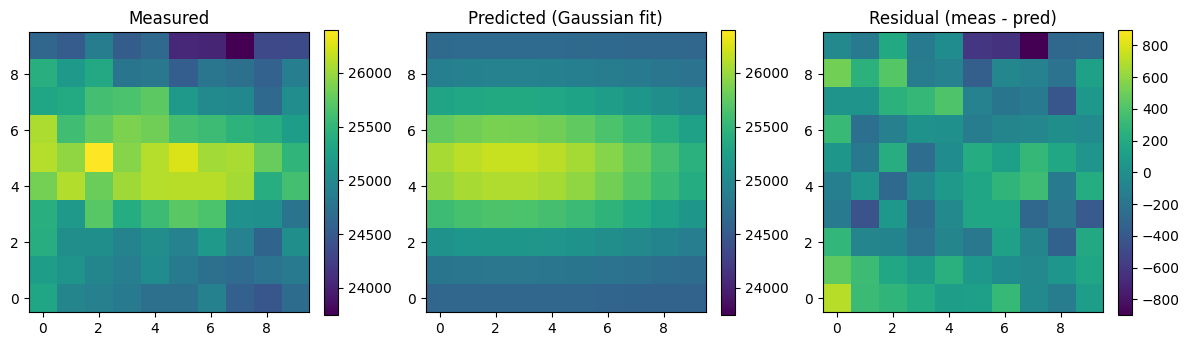

In [ ]:
plt.figure(figsize=(12, 4))

vmin = min(z.min(), pred.min())
vmax = max(z.max(), pred.max())

plt.subplot(1, 3, 1)
plt.title("Measured")
plt.imshow(z, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 2)
plt.title("Predicted (Gaussian fit)")
plt.imshow(pred, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 3)
plt.title("Residual (meas - pred)")
m = np.max(np.abs(resid))
plt.imshow(resid, origin="lower", vmin=-m, vmax=m)
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()

In [ ]:
raise NotImplementedErrort

{'x': 0.00017867907371876146, 'y': 2.2468651454170728e-05, 'z': 0.0001051607}


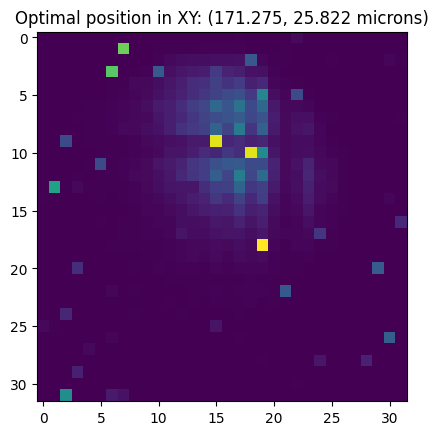

In [ ]:
# SAVE IN CASE NEED TO FIT XZ OR XY
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, offset):
    x, y = xy
    g = offset + amplitude * np.exp(
        -(((x - xo) ** 2) / (2 * sigma_x ** 2) + ((y - yo) ** 2) / (2 * sigma_y ** 2))
    )

    # add distance from center penalty
    return g.ravel()



initial_guess = (
    np.max(nv_brightness),  # amplitude
    curr_pos['x'],  # xo (center x)
    curr_pos['y'],  # yo (center y)
    scan_range_x / 4,  # sigma_x
    scan_range_y / 4,  # sigma_y
    np.min(nv_brightness)  # offset
)

position_opt, _ = curve_fit(
    gaussian_2d, 
    (X.ravel(), Y.ravel()), 
    nv_brightness.ravel(), 
    p0=initial_guess
)

amplitude, xo, yo, sigma_x, sigma_y, offset = position_opt

fit = gaussian_2d((X, Y), *position_opt).reshape(resolution_x, resolution_y)

pos_dict['x'], pos_dict['y'] = float(xo), float(yo)
position = piezo.set_target_position(pos_dict, move_blocking=True)
frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
frame = np.flipud(frame)
plt.title(f"Optimal position in XY: ({xo*10**6:.3f}, {yo*10**6:.3f} microns)")
plt.imshow(frame)